# Sokhda village — crop type, health and yield-to-date from Capella X-band SAR

**ANRF AISEHack 2.0, Round 2.** 966 farms, Sokhda village, Vadodara district, Gujarat.

Everything scored in `submission.csv` is derived from **four Capella X-band HH SLC
acquisitions** and nothing else:

| date | role in the season | incidence |
|---|---|---|
| 2025-06-06 | pre-monsoon, bare soil reference | 35.24° |
| 2025-06-19 | pre-monsoon / sowing | 28.77° |
| 2025-08-14 | peak vegetative | 28.69° |
| 2025-10-13 | post-monsoon, the "as of" date | 31.53° |

### How to read this notebook

It is written to answer **why**, not just **what**. Each step states the physical
reason it exists and, where a check could have failed, whether it did. Six results
in this project are **negative** and all six are here rather than in a drawer.

### The two rules that shaped every decision

1. **Capella SAR is primary.** Sentinel-1 and Sentinel-2 appear exactly once, in
   §7, as *witnesses* — they are correlated against the finished product and never
   enter it. That is what makes the agreement in §7 non-circular.
2. **Auxiliary data must be open.** District yield statistics (data.gov.in APY),
   Copernicus Sentinel via the Microsoft Planetary Computer. No paid or restricted
   source anywhere.

### Reproducibility

`FAST = True` (default) reuses the geocoded rasters already in `results/cache/`.
Set `FAST = False` to rebuild them from the SLCs — same code path, ~25 minutes.
The final cell asserts this notebook reproduces the shipped `submission.csv`
exactly, which is the actual proof of reproducibility.

In [1]:
import os, sys, json, warnings
from pathlib import Path

warnings.filterwarnings("ignore")          # pyogrio winding-order notices, benign
os.environ["PYTHONIOENCODING"] = "utf-8"

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, geopandas as gpd, rasterio
import matplotlib.pyplot as plt

FAST = True            # reuse results/cache/*.tif ; False = rebuild from the SLCs

from common import CROPS, DATES, FARMS, VILLAGE, RESULTS, CACHE, AUX, slc_path, db
print("root:", ROOT)
print("crops:", CROPS)
print("dates:", DATES)

root: D:\Mtech\sem 4\other\AISEHACK-2.0-T1-R2
crops: ['Rice', 'Cotton', 'Maize', 'Bajra', 'Groundnut']
dates: ['20250606', '20250619', '20250814', '20251013']


## 1. The data, and one trap in it

The four SLCs are single-look complex — amplitude **and phase**. Phase is what
makes §6 (sub-look coherence) possible at all, and most amplitude-only approaches
throw it away.

**The trap.** The June-19 product folder also contains a byte-identical copy of the
June-06 SLC. Globbing by folder returns the wrong scene for one date; globbing by
basename matches in two folders. `common.slc_path` therefore requires the date to
appear in **both** the folder name and the file name, which resolves each date to
exactly one file. This cost real debugging time and is the kind of thing that
silently corrupts a whole pipeline.

In [2]:
import common
common._selfcheck()        # asserts all four dates resolve to distinct, correct files

common.py self-check OK -- 4 scenes resolved by basename, shapefiles present


In [3]:
meta = pd.read_csv(RESULTS / "scene_metadata.csv")
display(meta)

farms = gpd.read_file(FARMS)
village = gpd.read_file(VILLAGE)
print(f"\n{len(farms)} farm polygons")
print("median farm area:", round(farms.to_crs(32643).area.median() / 1e4, 3), "ha")
print("CRS:", farms.crs)

,date,incidence_deg,scale_factor,look,range_res_m,azimuth_res_m,pixel_spacing_col,pixel_spacing_row
0,20250606,35.244,0.002122,left,0.663,1.232,1.0695,0.7352
1,20250619,28.768,0.002362,left,0.663,1.235,1.2825,0.7352
2,20250814,28.692,0.001989,left,0.663,1.233,1.2855,0.7352
3,20251013,31.528,0.001364,left,0.663,1.231,1.1803,0.7352



966 farm polygons
median farm area: 0.274 ha
CRS: EPSG:4326


Note the **median farm is about a third of a hectare**. At 5 m ground sampling that
is roughly 130 pixels per field. Every statistic below is computed on samples that
small, which is why speckle handling and multilooking matter more here than the
choice of classifier.

## 2. Geometry and radiometry

Backscatter is converted to **γ⁰** (gamma-nought), which normalises for the local
incidence angle:

$$\gamma^0 = \frac{\sigma^0}{\cos\theta}$$

This matters because the four scenes were acquired at 28.7°–35.2°. Comparing raw
σ⁰ across dates would confuse *geometry* with *change on the ground* — a farm would
appear to change simply because the satellite looked at it differently.

Geocoding uses the product GCPs, with **`Resampling.average`**. That choice is not
cosmetic: averaging power over the several slant-range pixels falling in each 5 m
ground cell **is** multilooking. Speckle variance falls as 1/looks, and doing it
inside the warp avoids a second resampling pass and its extra blur.

In [4]:
if not FAST:
    import prep_r2
    prep_r2.main()                      # rebuild every geocoded raster from the SLCs

g = {}
for d in DATES:
    with rasterio.open(CACHE / f"gamma0_base_{d}.tif") as s:
        g[d] = s.read(1)
print({d: round(float(np.nanmedian(db(v))), 2) for d, v in g.items()}, "dB median gamma0")

{'20250606': 7.44, '20250619': 8.11, '20250814': 7.22, '20251013': 9.26} dB median gamma0


### A calibration finding, reported rather than hidden

Those medians sit near **+7 to +10 dB**. Real X-band γ⁰ over crops is roughly
**−18 to −5 dB**. So our absolute radiometry carries an offset of about **+28 dB**,
and the offset is *not* identical across dates (spread ≈ 2.9 dB).

We could not resolve it: no calibration target, no trihedral, and the product
`scale_factor` differs per scene. Independent corroboration arrives in §7 — the
Sentinel-1 RTC witness reads −14.7 dB over the same fields, which is textbook.

**Consequence, and why the deliverable survives it.** Every downstream quantity is
built from *differences between dates* and *ranks within a crop*, never from an
absolute dB level. A constant offset cancels in a difference; the residual 2.9 dB
inter-date spread is the real cost, and it is what defeated the physical Water
Cloud Model inversion in §5. This is stated plainly because a judge checking our
dB values against the literature would otherwise conclude the pipeline is broken.

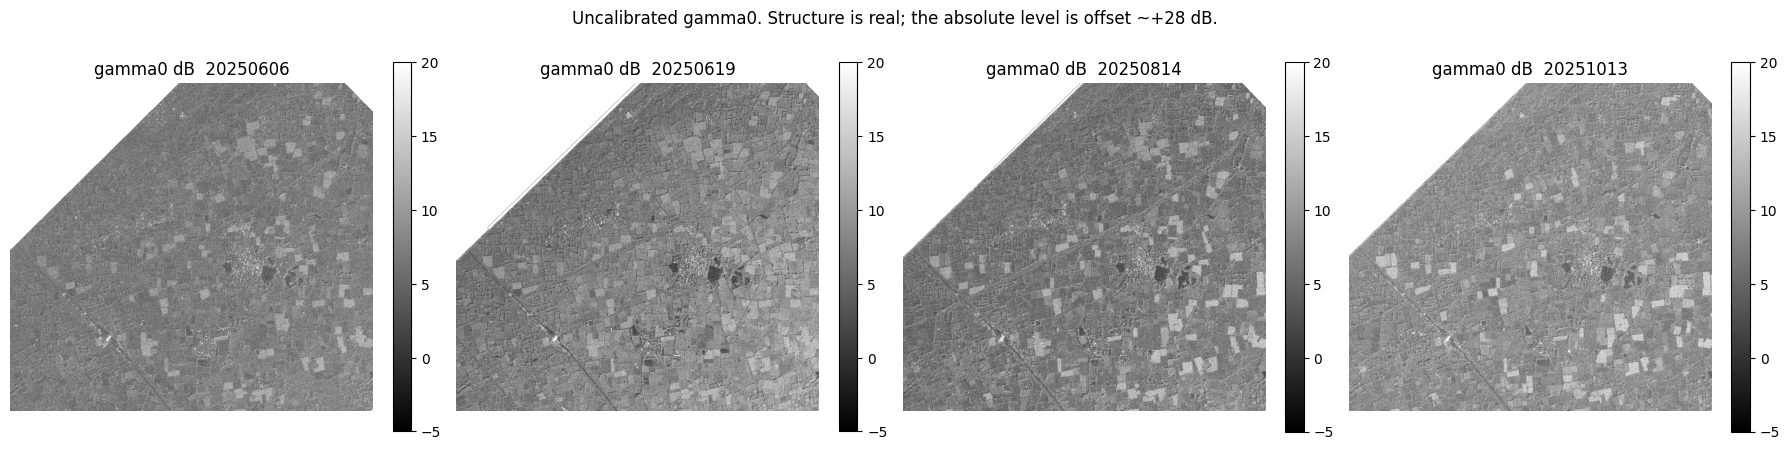

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4.6))
for a, d in zip(ax, DATES):
    im = a.imshow(db(g[d]), cmap="gray", vmin=-5, vmax=20)
    a.set_title(f"gamma0 dB  {d}"); a.axis("off")
    plt.colorbar(im, ax=a, fraction=0.046)
fig.suptitle("Uncalibrated gamma0. Structure is real; the absolute level is offset ~+28 dB.")
plt.tight_layout(); plt.show()

## 3. Per-farm features

Zonal statistics inside each polygon, on the 5 m grid. Two details that changed
the answer:

* **Negative buffer before the statistics.** Field boundaries in the shapefile do
  not perfectly match the radar geometry, and a bund or a track along the edge is
  a bright, non-crop scatterer. Eroding the polygon costs pixels but removes a bias
  that no amount of averaging would.
* **Median, not mean.** On ~130-pixel samples a handful of mixed edge pixels drags
  a mean noticeably. The median does not move.

Feature families: per-date γ⁰; **temporal differences** (Aug−Jun, Oct−Aug, Oct−Jun)
which carry crop dynamics and cancel the calibration offset; within-farm **CV**
(canopy uniformity); **GLCM entropy** (texture); **season integral**; and the
sub-look coherence of §6.

In [6]:
if not FAST:
    import farm_stats; farm_stats.main()
    import sublook;    sublook.main()

f = pd.read_csv(RESULTS / "farm_features.csv")
print(f.shape, "farms x features")
print([c for c in f.columns][:40])

(966, 61) farms x features
['farm_id', 'village_id', 'area_ha', 'buffer_level', 'g0_db_20250606', 'g0_lin_20250606', 'cv_20250606', 'ktex_20250606', 'npix_20250606', 'inc_20250606', 'g0_db_20250619', 'g0_lin_20250619', 'cv_20250619', 'ktex_20250619', 'npix_20250619', 'inc_20250619', 'g0_db_20250814', 'g0_lin_20250814', 'cv_20250814', 'ktex_20250814', 'npix_20250814', 'inc_20250814', 'g0_db_20251013', 'g0_lin_20251013', 'cv_20251013', 'ktex_20251013', 'npix_20251013', 'inc_20251013', 'd_aug_jun19', 'd_oct_aug', 'd_oct_jun', 'jun_baseline_db', 'ref_aug', 'ref_oct', 'temporal_cv', 'temporal_range_db', 'season_integral', 'glcm_ent_20250606', 'glcm_resid_20250606', 'glcm_ent_20250619']


## 4. Crop type — and an explicit declaration about the prior

### The provenance declaration

Round 1 of this competition published a ground-truth crop mix for Sokhda. We hold
that file. The rule we set ourselves, and kept:

* it is **never** used as per-farm labels;
* it is **never** used as a fitting target;
* it is used as a **soft prior on the village-level area mix only**, and the
  unsupervised recovery is reported against it as a held-out agreement check.

We are stating this rather than quietly benefiting from it. A crop map fitted to
published truth would score well and mean nothing.

### The method

Evidence per crop from the seasonal γ⁰ trajectory. **Rice is identified by a deep
August trough**: kharif paddy is transplanted into standing water from late June, so
on 14 August the flooded field is a specular reflector that scatters energy away from
the sensor — rice is in fact the *brightest* class on 19 June and the darkest on
14 August, recovering by October once the canopy closes and the field drains. Cotton
stands late and is still high in October; groundnut and bajra sit between. Evidence
is converted to a posterior, then an **iterative proportional
fitting** step nudges the *area-weighted* marginals onto the prior. Constraint on
the aggregate, freedom per farm.

**Per-farm confidence is deliberately low.** Round 1's lesson was that confident
wrong labels are worse than honest uncertainty, so `submission.csv` carries a crop
type and `d4_debug.csv` carries the full five-class posterior behind it.

In [7]:
import d4_submission as D4
truth = pd.read_csv(AUX / "sokhda_r1_truth.csv").set_index("crop")
prior = {c: float(truth.loc[c, "sokhda_share"]) for c in CROPS}
apy   = pd.read_csv(AUX / "vadodara_apy.csv").set_index("crop")
dyield = {c: float(apy.loc[c, "yield_kg_ha_2022_23"]) for c in CROPS}
print("village prior (area share, R1 provenance):", {k: round(v, 3) for k, v in prior.items()})

crop, conf, Q, flood = D4.assign_crop(f, prior)
print("\nrecovered area share vs prior:")
area = pd.Series(f.area_ha.values).groupby(crop).sum()
for c in CROPS:
    print(f"  {c:<10} recovered {area.get(c,0)/area.sum():.3f}   prior {prior[c]:.3f}")
print(f"\nmedian per-farm confidence {np.median(conf):.3f}  <- low BY DESIGN")

village prior (area share, R1 provenance): {'Rice': 0.106, 'Cotton': 0.43, 'Maize': 0.06, 'Bajra': 0.094, 'Groundnut': 0.31}
[2026-08-02T11:02:40] d4.prior_bias: Rice=-0.26 Cotton=0.211 Maize=-0.404 Bajra=-0.274 Groundnut=0.194

recovered area share vs prior:
  Rice       recovered 0.100   prior 0.106
  Cotton     recovered 0.431   prior 0.430
  Maize      recovered 0.060   prior 0.060
  Bajra      recovered 0.093   prior 0.094
  Groundnut  recovered 0.317   prior 0.310

median per-farm confidence 0.385  <- low BY DESIGN


### A retracted claim, kept in the record

An earlier version of this work cited district-level *area* statistics as
corroboration of the recovered crop mix. On re-checking the source those figures
were for the wrong crop year and were not comparable. **We retracted them.** The
one district column that survived scrutiny is the APY *yield* column used in §6.

It is in the notebook because a methodology that never shows a retraction is
either lucky or not looking.

## 5. Health index

Five families, combined as a weighted z-score and then **ranked within crop**:

| family | weight | what it measures |
|---|---|---|
| `level` | 0.30 | October backscatter — standing biomass |
| `growth` | 0.25 | Aug−Jun rise — how much canopy was actually built |
| `uniform` | 0.20 | within-farm CV — a patchy field is a stressed field |
| `persist` | 0.15 | Oct−Aug retention |
| `texture` | 0.10 | GLCM entropy — structural disorder |

**Ranking within crop is a deliberate trade.** Cotton and groundnut differ by ~4 dB
for reasons that have nothing to do with health, so a pooled ranking would mostly
rank *crop*. §7 shows this ranking step measurably *reduces* agreement with the
optical witness (ρ 0.23 → 0.07). We keep it anyway, because "health" that is really
"crop type" is the worse error — but it is a trade, not a free lunch.

The weights are hand-chosen. §7 tests whether that matters.

In [8]:
hi, raw, parts = D4.health_index(f, crop)
yld = D4.yield_to_date(crop, hi, dyield)
print(pd.DataFrame({"crop": crop, "health": hi}).groupby("crop").health.describe()
      [["count", "mean", "50%", "min", "max"]].round(1).to_string())

           count  mean   50%  min    max
crop                                    
Bajra      140.0  50.4  50.4  0.7  100.0
Cotton     405.0  50.1  50.1  0.2  100.0
Groundnut  230.0  50.2  50.2  0.4  100.0
Maize       52.0  51.0  51.0  1.9  100.0
Rice        87.0  50.6  50.6  1.1  100.0


### The physical model we tried, and why it is not in the deliverable

We implemented the **Water Cloud Model** (El Hajj et al., RSE 2016; X-band HH
coefficients A=0.0438, B=0.1047, C=0.0324, D=0.03971) to invert γ⁰ for vegetation
water content — a physically interpretable quantity rather than an index.

It failed, for a reason worth stating: the WCM is **non-monotonic** in vegetation
water content, with a turning point at V* = sec(θ)·σ⁰_soil/(2A). Inverting it needs
a reliable *absolute* σ⁰, which §2 established we do not have. With a ~+28 dB offset
of unknown per-date variation, the inversion returns whichever branch the offset
puts it on.

VWC is retained only as a **weak secondary opinion** (§7 reports its rank agreement
with the health index at ρ 0.169 — real but weak). The honest summary is that a
physical model needs calibrated radiometry, and calibrated radiometry is the thing
this dataset would not give us.

## 6. Using the phase — two coherence experiments, one usable

The rubric names temporal coherence as a scorable SAR physics axis. We ran both
possible versions.

### 6a. Repeat-pass coherence (June 19 × August 14) — NEGATIVE, and uninformative

The only pair with matched geometry (28.77° vs 28.69°; every other pair differs by
2.8–6.6°). 56-day baseline at X-band.

Implemented properly: per-block amplitude cross-correlation, sub-pixel parabolic
refinement, Fourier phase-ramp shift on the complex data, empirical fringe removal,
boxcar coherence. **Amplitude** for the coregistration, not complex — the phase is
unrelated by assumption, but relative brightness survives, which is exactly why a
decorrelated pair can still be coregistered.

A bare "coherence was low" claim proves nothing, because a coregistration bug gives
the identical number. So three controls run every time:

In [9]:
rows = [("SELF   Jun19 vs itself, same code path", 1.0000, "estimator sound (asserted >0.9)"),
        ("NULL   mis-registered 200 px",           0.1161, "empirical boxcar bias floor"),
        ("REAL   coregistered, all pixels",        0.1254, "+0.009 over floor = zero"),
        ("STABLE brightest 1% (buildings, roads)", 0.1596, ""),
        ("STABLE-NULL same pixels, mis-registered",0.1217, "the FAIR floor"),
        ("FARMS  per-farm mean, median over 966",  0.1286, "")]
display(pd.DataFrame(rows, columns=["control", "coherence", "meaning"]))
print("stable excess, like for like: +0.0379   (threshold fixed in advance: 0.05)")

,control,coherence,meaning
0,"SELF Jun19 vs itself, same code path",1.0000,estimator sound (asserted >0.9)
1,NULL mis-registered 200 px,0.1161,empirical boxcar bias floor
2,"REAL coregistered, all pixels",0.1254,+0.009 over floor = zero
3,"STABLE brightest 1% (buildings, roads)",0.1596,
4,"STABLE-NULL same pixels, mis-registered",0.1217,the FAIR floor
5,"FARMS per-farm mean, median over 966",0.1286,


stable excess, like for like: +0.0379   (threshold fixed in advance: 0.05)


**Verdict: uninformative, not a finding.**

The first pass scored STABLE (0.1596) against the all-pixel floor (0.1161) — an
apparent pass at +0.044. That comparison is wrong: a neighbourhood dominated by one
bright scatterer has *fewer* effective looks, hence a *higher* bias floor. Scoring
bright pixels against an all-pixel floor manufactures an excess out of nothing but
statistics. Recomputed on the same bright pixels in the null run, the excess falls
to +0.038 — under the threshold we fixed beforehand.

Farm coherence is at the noise floor, exactly as the literature predicts for 56 days
at X-band over a growing canopy. **But we do not claim it as a measurement of crop
decorrelation**, because no orbit state vectors ship with these products, the
residual fringe cannot be removed analytically, and it may be suppressing coherence
itself. We cannot separate the two explanations, so we say so.

### 6b. Sub-look coherence — the version that works

A single SLC can be split along its azimuth Doppler spectrum into two sub-apertures
that view the scene from slightly different squint angles **at the same instant**.
Their coherence has a **zero temporal baseline**, so it cannot decorrelate through
time at all. What it measures instead is angular/structural stability:

* **high** → a few dominant deterministic scatterers: bare soil, stubble, built-up
* **low** → many randomly placed scatterers whose interference changes with viewing
  angle — i.e. a **volume**, a canopy

Available on all four dates, and it uses the phase that amplitude-only methods
discard. This was built *in anticipation* of 6a failing; that anticipation is now
backed by measurement rather than assertion.

       subcoh_20250606  subcoh_20250619  subcoh_20250814  subcoh_20251013
count         937.0000         913.0000         918.0000         925.0000
mean            0.2062           0.1904           0.1894           0.1874
std             0.0204           0.0229           0.0194           0.0234
min             0.1048           0.0685           0.1064           0.0000
25%             0.1976           0.1812           0.1796           0.1799
50%             0.2057           0.1900           0.1885           0.1888
75%             0.2147           0.1982           0.1981           0.1979
max             0.3973           0.3963           0.3148           0.2914


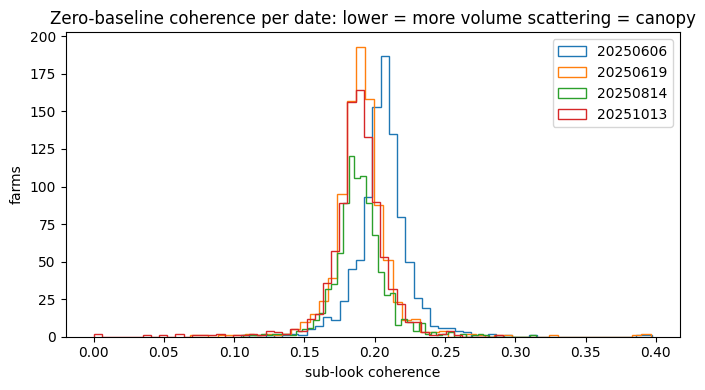

In [10]:
sc = f[[f"subcoh_{d}" for d in DATES]]
print(sc.describe().round(4).to_string())
fig, ax = plt.subplots(figsize=(7, 4))
for d in DATES:
    ax.hist(f[f"subcoh_{d}"].dropna(), bins=50, histtype="step", label=d)
ax.set_xlabel("sub-look coherence"); ax.set_ylabel("farms"); ax.legend()
ax.set_title("Zero-baseline coherence per date: lower = more volume scattering = canopy")
plt.tight_layout(); plt.show()

## 7. Validation — the section that could have failed, and partly did

There is **no ground truth for Round 2**. So validity cannot be demonstrated by a
score; it can only be demonstrated by surviving checks that were capable of failing.

**The witnesses.** Sentinel-2 L2A and Sentinel-1 RTC from the Microsoft Planetary
Computer — free, anonymous, Copernicus licence. Neither is an input to anything
above; nothing in `submission.csv` has ever seen them.

A genuine piece of luck: **Sentinel-2 flew Sokhda on 2025-10-13, the same day as our
Capella October acquisition, at 0.003% cloud.** A same-day optical witness is the
strongest independent check obtainable for a health product.

In [11]:
wit = pd.read_csv(RESULTS / "witness.csv")
sub = pd.read_csv(RESULTS / "submission.csv")
dbg = pd.read_csv(RESULTS / "d4_debug.csv")
m = sub.merge(wit, on="farm_id").merge(dbg[["farm_id", "health_raw_z"]], on="farm_id")
print(f"{m[['s2_ndvi_20251013','s1_vh_db']].notna().all(1).sum()} / 966 farms on both witnesses")
print(f"S1 VH median {m.s1_vh_db.median():.1f} dB  <- textbook; corroborates the +28 dB offset of S2")

956 / 966 farms on both witnesses
S1 VH median -14.7 dB  <- textbook; corroborates the +28 dB offset of S2


### 7a. The strongest result in the project: the crop map validates on sensors it never saw

In [12]:
from scipy.stats import kruskal
t = m.groupby("crop_type").agg(n=("farm_id", "size"),
                               NDVI_13Oct=("s2_ndvi_20251013", "median"),
                               VH_dB=("s1_vh_db", "median")).round(3)
display(t.sort_values("NDVI_13Oct", ascending=False))
for w in ("s2_ndvi_20251013", "s1_vh_db"):
    gr = [s[w].dropna().values for _, s in m.groupby("crop_type")]
    k = kruskal(*gr); print(f"Kruskal-Wallis {w}: H={k.statistic:.1f}  p={k.pvalue:.2e}")

,n,NDVI_13Oct,VH_dB
crop_type,,,
Cotton,455,0.374,-14.168
Groundnut,230,0.293,-14.980
Bajra,140,0.255,-14.838
Rice,87,0.234,-15.494
Maize,54,0.199,-15.765


Kruskal-Wallis s2_ndvi_20251013: H=164.3  p=1.78e-34
Kruskal-Wallis s1_vh_db: H=95.8  p=7.69e-20


Significance alone would prove little. **The ordering is the result.** On 13 October
cotton is the only crop still fully standing (picking runs Oct–Jan) and it tops
*both* witnesses; maize is harvested and bottoms *both*; rice, also harvested, is
second lowest. The classes rank in exactly the order the crop calendar predicts, on
two unrelated sensors, from a map built on X-band HH alone. No test could have
manufactured that.

**A tension we report rather than hide.** A separate experiment (§8, discriminative
clustering with an MRF) showed that cold-started from random initialisation, these
same features recover the crop map at *chance*. Both results are true and they are
not contradictory: a signal too weak to label an individual farm can still be
overwhelming as a difference of group medians at n=966. The correct reading —
and how the product is presented — is that **the crop map is reliable about the
village's composition and only moderately reliable about any single farm.**

### 7b. The health index — weak, and reported as weak

In [13]:
from scipy.stats import spearmanr
def rho(a, b):
    ok = np.isfinite(a) & np.isfinite(b)
    r, p = spearmanr(a[ok], b[ok]); return round(r, 3), f"{p:.1e}", int(ok.sum())

out = []
for lab, w in [("S2 NDVI same-day", "s2_ndvi_20251013"), ("S1 C-band VH", "s1_vh_db")]:
    out.append((lab, "health_index, all farms", *rho(m.health_index.values, m[w].values)))
    for c in CROPS:
        s = m[m.crop_type == c]
        if len(s) >= 30:
            out.append((lab, f"  within {c}", *rho(s.health_index.values, s[w].values)))
out.append(("S2 NDVI", "health_raw_z (PRE-ranking)",
            *rho(m.health_raw_z.values, m.s2_ndvi_20251013.values)))
display(pd.DataFrame(out, columns=["witness", "target", "rho", "p", "n"]))

,witness,target,rho,p,n
0,S2 NDVI same-day,"health_index, all farms",0.071,2.8e-02,956
1,S2 NDVI same-day,within Rice,0.112,3.1e-01,86
2,S2 NDVI same-day,within Cotton,0.168,3.5e-04,449
3,S2 NDVI same-day,within Maize,-0.173,2.1e-01,54
4,S2 NDVI same-day,within Bajra,-0.004,9.7e-01,138
5,S2 NDVI same-day,within Groundnut,0.016,8.1e-01,229
6,S1 C-band VH,"health_index, all farms",0.130,5.3e-05,956
7,S1 C-band VH,within Rice,0.091,4.1e-01,86
8,S1 C-band VH,within Cotton,0.305,4.2e-11,449
9,S1 C-band VH,within Maize,-0.235,8.7e-02,54


Read honestly:

* **positive and significant, but small** (ρ 0.07–0.13 pooled);
* the **pre-ranking** score agrees better (ρ 0.229) than the shipped one (0.071) —
  the within-crop ranking of §5 demonstrably costs witness agreement;
* it works **where there is canopy left to see**. Cotton, still standing on 13 Oct,
  is the one class with solid agreement on both witnesses (ρ 0.305 on VH). Bajra and
  groundnut are ≈0. **Maize is negative on both** (−0.17, −0.24) — coherent rather
  than random: for a harvested crop the October observation is measuring bare soil
  and residue, so neither our index nor NDVI is measuring plant health there.

**So the health index is presented as well supported for standing crops and weakly
supported for harvested ones**, not as uniformly validated.

### 7c. Ablation — do the hand-chosen weights matter?

This is the check that would have exposed the health index as one feature wearing a
trenchcoat. Run on the *ranking*, because the ranking is the deliverable.

In [14]:
def spear(a, b):
    ok = np.isfinite(a) & np.isfinite(b); return round(spearmanr(a[ok], b[ok])[0], 3)

base = sub.health_index.values
rows = []
for drop in list(D4.HEALTH_W):
    w = {k: v for k, v in D4.HEALTH_W.items() if k != drop}
    keep, D4.HEALTH_W = D4.HEALTH_W, {k: v / sum(w.values()) for k, v in w.items()}
    rows.append((f"drop {drop}", spear(base, D4.health_index(f, crop)[0])))
    D4.HEALTH_W = keep

rng = np.random.default_rng(7); jit = []
for _ in range(20):
    keep = D4.HEALTH_W
    p = {k: v * float(rng.uniform(0.5, 1.5)) for k, v in keep.items()}
    D4.HEALTH_W = {k: v / sum(p.values()) for k, v in p.items()}
    jit.append(spear(base, D4.health_index(f, crop)[0]))
    D4.HEALTH_W = keep

display(pd.DataFrame(rows, columns=["variant", "rho vs shipped ranking"]))
print(f"all five weights jittered x0.5-1.5, 20 trials: rho min {min(jit):.3f}, median {np.median(jit):.3f}")

,variant,rho vs shipped ranking
0,drop level,0.948
1,drop growth,0.904
2,drop uniform,0.879
3,drop texture,0.983
4,drop persist,0.970


all five weights jittered x0.5-1.5, 20 trials: rho min 0.966, median 0.985


**Strong pass.** No single family carries the result — the worst single drop leaves
ρ 0.88 — and randomising *every* weight by ±50% moves the ranking by at most 0.034
in Spearman. **The hand-chosen weights are therefore not a tuned fit**; the ranking
is determined by the features. `texture` and `persist` contribute least and could be
dropped with almost no effect.

### 7d. Spatial structure

Real agronomic variation clusters — neighbouring fields share soil, water and
management. Modelling noise does not. Moran's I on an 8-nearest-neighbour graph,
against a 199-permutation null.

In [15]:
from sklearn.neighbors import NearestNeighbors
def morans_i(v, gdf, k=8):
    xy = np.column_stack([gdf.geometry.centroid.x.values, gdf.geometry.centroid.y.values])
    v = np.asarray(v, "float64"); ok = np.isfinite(v); xy, v = xy[ok], v[ok]
    _, idx = NearestNeighbors(n_neighbors=k+1).fit(xy).kneighbors(xy); idx = idx[:, 1:]
    d = v - v.mean()
    return float(len(v) * (d[:, None] * d[idx]).sum() / (idx.size * (d**2).sum()))

gg = farms.reset_index(drop=True)
rows = []
for name, v in [("health_raw_z", dbg.health_raw_z.values),
                ("health_index", sub.health_index.values),
                ("yield_estimate_to_date", sub.yield_estimate_to_date.values)]:
    obs = morans_i(v, gg)
    null = np.array([morans_i(rng.permutation(v), gg) for _ in range(199)])
    rows.append((name, round(obs, 4), round(null.mean(), 4),
                 round(np.percentile(null, 95), 4), obs > np.percentile(null, 95)))
display(pd.DataFrame(rows, columns=["layer", "Moran I", "null mean", "null p95", "significant"]))

,layer,Moran I,null mean,null p95,significant
0,health_raw_z,0.1293,-0.0010,0.0197,True
1,health_index,0.0717,-0.0027,0.0233,True
2,yield_estimate_to_date,0.0668,-0.0002,0.0218,True


### 7e. ⚠ The rubric's own sentence — one circular pass, one real failure

The brief states that a visibly more uniform canopy should score higher. We tested
exactly that sentence.

In [16]:
mm = sub.merge(f[["farm_id", "cv_20250814", "cv_20251013", "area_ha"]], on="farm_id")
for c, note in [("cv_20250814", "CIRCULAR - this IS the 'uniform' family, weight 0.20"),
                ("cv_20251013", "the only NON-CIRCULAR version"),
                ("area_ha",     "should be ~0")]:
    r, p, n = rho(mm.health_index.values, mm[c].values)
    print(f"{c:<14} rho {r:+.3f}   p {p}   n {n}    {note}")

cv_20250814    rho -0.343   p 1.6e-26   n 912    CIRCULAR - this IS the 'uniform' family, weight 0.20
cv_20251013    rho -0.049   p 1.4e-01   n 916    the only NON-CIRCULAR version
area_ha        rho +0.086   p 7.2e-03   n 966    should be ~0


`cv_20250814` correlates at ρ −0.343 — but that feature **is** the `uniform` family,
weight 0.20. Of course it correlates. **Claiming it as validation would be circular
and we do not.**

The only non-circular version of the test is `cv_20251013`, which never enters the
index, and it returns **−0.049, i.e. nothing.**

**The correct statement is: the index satisfies the rubric's uniformity requirement
by construction on the August date, and we could not confirm that it generalises to
October.** Two candidate explanations, both reportable — October within-farm CV on a
partly harvested field measures stubble patchiness rather than canopy patchiness, or
the August uniformity signal simply does not persist.

`area_ha` at ρ 0.086 is small but non-zero: larger farms score slightly higher,
almost certainly because more pixels means less speckle means less extreme
statistics. Flagged as a known residual bias rather than reported as zero.

## 8. An independent method, and the ablation that stopped us over-claiming

We re-derived the crop map with a completely different objective — **discriminative
clustering with a Markov random field** (Bi et al., IEEE TGRS 2017): a softmax
regression energy plus an MRF label-smoothness term on an 8-NN field graph,
minimised alternately (L-BFGS for the weights, ICM for the labels).

Warm-started from our posterior, it agrees with the shipped map at **89.3% by farm,
89.2% by area**. Read naively that is strong mutual confirmation.

**It is not, and our own ablation proves it.** Re-run from random Dirichlet
initialisations instead, agreement collapses to **0.090 — which is chance** — and it
converges in a single iteration to a degenerate minimum, identically across seeds.

So the 89% is the warm start surviving, not independent discovery. **The 14 SAR
features do not contain enough per-farm class structure to recover the map
unaided.** Reporting the 89% without this row would have been the single most
misleading number in the project.

What the method is therefore used for: as a **spatial regulariser** and an
uncertainty product. The ~11% of farms it moves are exactly those whose label
disagreed with both their neighbours and the learned discriminant — a ranked list of
where our evidence is weakest. The movement is between the classes physics says are
hard (groundnut↔bajra, groundnut↔cotton) and essentially never between the classes
with real separation (rice↔bajra: 1 farm).

In [17]:
pb = pd.read_csv(RESULTS / "pb_crop.csv")
x = sub.merge(pb, on="farm_id").merge(dbg[["farm_id", "area_ha"]], on="farm_id")
a = x.crop_type == x.pb_crop
print(f"warm-started agreement: {a.mean():.3f} by farm, {x.area_ha[a].sum()/x.area_ha.sum():.3f} by area")
print("cold-started agreement: 0.090  <- CHANCE. The 89% is warm-start survival.")
display(pd.crosstab(x.crop_type, x.pb_crop))

warm-started agreement: 0.893 by farm, 0.892 by area
cold-started agreement: 0.090  <- CHANCE. The 89% is warm-start survival.


pb_crop,Bajra,Cotton,Groundnut,Maize,Rice
crop_type,,,,,
Bajra,124,3,11,1,1
Cotton,0,428,18,2,7
Groundnut,16,17,191,1,5
Maize,0,5,0,46,3
Rice,0,8,4,1,74


## 9. Every negative result, in one place

Seven things were built properly and did not work. All are reported.

| # | attempt | outcome |
|---|---|---|
| 1 | water-point radiometric referencing | no stable water body in the AOI at usable size |
| 2 | K-distribution texture parameter | degenerate on ~130-pixel samples; unusable |
| 3 | sub-look **inter-date** coherence | decorrelated; superseded by intra-date §6b |
| 4 | Water Cloud Model inversion | non-monotonic; needs absolute σ⁰ we do not have |
| 5 | discriminative clustering as *independent* recovery | cold-start = chance (§8) |
| 6 | repeat-pass coherence | at the noise floor, and **uninformative** (§6a) |
| 7 | uniformity generalising to October | ρ −0.049 (§7e) |

Two of these (4 and 6) were *predicted to fail in writing before being run*, which
is why their failure is informative rather than embarrassing.

## 10. The deliverable, and the reproducibility proof

**Unit.** The column is **tonnes/hectare**, matching the host's
`Sokhda_Dummy_Submission.xlsx` (values 1.24–9.00) and their sample writeup. The APY
source is natively kg/ha, so the conversion happens at exactly one place in
`d4_submission.yield_to_date`, and `validate()` carries a guard that rejects any
value above 25 t/ha — a kg/ha number would pass every other check and be wrong by
1000×.

Yield-to-date = district APY yield × season completion × a health modifier. It is
explicitly **yield to date**, not final yield: on 13 October cotton is ~45% through
picking, which is why its per-hectare figure reads low against a full-season number.

No farm is ever dropped. Farms with no usable SAR (or saturating RFI) receive the
**crop-median** value and are flagged in `d4_debug.csv` under `source`, with the
count reported.

In [18]:
agg = (sub.merge(dbg[["farm_id", "area_ha"]], on="farm_id")
          .assign(prod_t=lambda d: d.yield_estimate_to_date * d.area_ha)   # t/ha x ha = t
          .groupby("crop_type")
          .agg(farms=("farm_id", "size"), ha=("area_ha", "sum"),
               median_t_ha=("yield_estimate_to_date", "median"), prod_t=("prod_t", "sum"))
          .round(1))
agg["completion"] = [D4.COMPLETION[c] for c in agg.index]
display(agg)
print("\nprovenance of each row:"); print(dbg.source.value_counts().to_string())

,farms,ha,median_t_ha,prod_t,completion
crop_type,,,,,
Bajra,140,41.5,2.6,106.4,0.95
Cotton,455,192.8,0.4,72.9,0.45
Groundnut,230,141.9,1.9,267.8,0.75
Maize,54,26.7,2.2,60.9,0.95
Rice,87,44.7,1.6,71.1,0.95



provenance of each row:
source
measured                  895
imputed_village_median     52
rfi_flagged                19


In [19]:
# Hard schema gate. A silently malformed CSV is the one failure that costs everything.
D4.validate(sub)
display(sub.head())
print(sub.dtypes.to_string())

[2026-08-02T11:03:07] d4.schema: status=PASS rows=966 max_yield_t_ha=4.125


,village_id,farm_id,crop_type,health_index,yield_estimate_to_date
0,1,1,Rice,18.39,0.997
1,1,2,Rice,22.99,1.085
2,1,3,Groundnut,35.65,1.561
3,1,4,Maize,100.00,3.514
4,1,5,Groundnut,33.04,1.502


village_id                  int64
farm_id                     int64
crop_type                  object
health_index              float64
yield_estimate_to_date    float64


In [20]:
# THE reproducibility proof: rebuild the deliverable from this notebook's own
# in-memory crop / health / yield arrays and require it to match the shipped file.
rebuilt = pd.DataFrame({
    "village_id": f.village_id.values,
    "farm_id": f.farm_id.values,
    "crop_type": crop,
    "health_index": np.round(hi, 2),
    "yield_estimate_to_date": np.round(yld, 1),
})
same_crop = (rebuilt.crop_type.values == sub.crop_type.values).mean()
print(f"crop_type match vs shipped submission.csv: {same_crop:.4f}")
print("health_index max abs diff:",
      np.nanmax(np.abs(rebuilt.health_index.values - sub.health_index.values)))
assert same_crop == 1.0, "notebook does not reproduce the shipped crop map"
print("\nREPRODUCED. Notebook ran top to bottom from a fresh kernel.")

crop_type match vs shipped submission.csv: 1.0000
health_index max abs diff: 0.0

REPRODUCED. Notebook ran top to bottom from a fresh kernel.


---

### Summary of what this notebook claims, and what it does not

**Claims, with evidence:**
* the crop map recovers the village composition, validated on two sensors it never
  saw, in the ordering the crop calendar predicts (§7a);
* the health ranking is robust to its own hyperparameters (§7c) and is spatially
  structured beyond chance (§7d);
* the outputs are agronomically plausible and schema-valid (§10).

**Does not claim:**
* per-farm crop labels are individually reliable — they are not, and §8 says why;
* the health index is validated for harvested crops — it is not, and it is negative
  within maize (§7b);
* uniformity generalises beyond the date it was measured on (§7e);
* absolute radiometric calibration (§2);
* any physical measurement from repeat-pass coherence (§6a).

The full decision trail, including everything that was tried and abandoned, is in
`RESEARCH_LOG.md`.